# Stage 1: PPG Signal Processing - At-Rest Data Analysis

## Learning Objectives

By the end of this notebook, you will be able to:
- Load and visualize PPG signals from the EarSet dataset
- Apply bandpass filtering to isolate cardiac components
- Detect systolic peaks in PPG waveforms
- Compute heart rate and heart rate variability metrics
- Assess signal quality
- Validate results against heartPy reference implementation

## Setup

Install required packages:
```bash
pip install numpy scipy pandas matplotlib jupyter pyPPG heartpy
```

Download the EarSet dataset:
- URL: https://zenodo.org/records/8142332/files/EarSet_v1.zip
- Download using wget
- Extract to a local directory

## References

Key papers for this stage:
- Goda, M. A., Charlton, P. H., & Behar, J. A. (2023). "pyPPG: A Python toolbox for comprehensive photoplethysmography signal analysis." IEEE Transactions on Biomedical Engineering, 70(11).
- Charlton, P. H., Marozas, V., Chowienczyk, P., & Białkowski, J. (2016). "Wearable photoplethysmography for cardiovascular monitoring." Proceedings of the IEEE, 104(11), 2288-2303.
- Allen, J. (2007). "Photoplethysmography and its application in clinical physiological measurement." Physiological Measurement, 28(3), R1.

In [ ]:
!pip install numpy scipy pandas matplotlib jupyter pyPPG heartpy dotmap -q

INFO: pip is looking at multiple versions of pyppg to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pyppg to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.7 MB/s eta 0:00:00
 

In [ ]:
!wget https://zenodo.org/records/8142332/files/EarSet_v1.zip -q
!unzip EarSet_v1.zip -q

--2026-03-12 22:04:34--  https://zenodo.org/records/8142332/files/EarSet_v1.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 325872119 (311M) [application/octet-stream]
Saving to: ‘EarSet_v1.zip’

EarSet_v1.zip       100%[===================>] 310.78M  21.6MB/s    in 17s     

2026-03-12 22:04:52 (18.3 MB/s) - ‘EarSet_v1.zip’ saved [325872119/325872119]

Archive:  EarSet_v1.zip
   creating: Dataset/
  inflating: __MACOSX/._Dataset      
   creating: Dataset/P4/
  inflating: __MACOSX/Dataset/._P4   
   creating: Dataset/P3/
  inflating: __MACOSX/Dataset/._P3   
   creating: Dataset/P2/
  inflating: __MACOSX/Dataset/._P2   
   creating: Dataset/P5/
  inflating: __MACOSX/Dataset/._P5   
   creating: Dataset/P19/
  inflating: __MACOSX/Dataset/._P19  
   creating: Dataset/P26/
  inflating: __MACOSX/Dataset/._P26  
   creati

## Section 1: Import Libraries and Set Paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

# TODO: Update these paths for your system
dataset_path = Path('/content/Dataset')
participant_id = '1'
ear = 'left'

print(f"Dataset path: {dataset_path}")
print(f"Looking for participant: {participant_id}")

Dataset path: /content/Dataset
Looking for participant: 1


## Section 2: Load and Explore Data

### Task 1.1: Load and Inspect Data

**Your task:** Load the PPG and IMU data from EarSet for your chosen participant. Plot the raw signals and compute basic statistics.

**What to examine:**
- What is the sampling frequency?
- How long is each recording?
- What are the amplitude ranges for PPG and accelerometer signals?
- Can you identify any obvious noise or artifacts visually?

In [ ]:
# Load PPG data
ppg_file = dataset_path / f'P{participant_id}' / 'EARBUDS' / f'{participant_id}-still-ppg-{ear}.csv'
ppg_data = pd.read_csv(ppg_file)

print("PPG Data Summary:")
print(ppg_data.head())
print(f"\nShape: {ppg_data.shape}")
print(f"Columns: {ppg_data.columns.tolist()}")
print(f"\nBasic statistics:")
print(ppg_data.describe())

# Set sampling frequency
fs = 100  # EarSet PPG sampling rate
ppg_duration = len(ppg_data) / fs
print(f"\nSampling frequency: {fs} Hz")
print(f"Total duration: {ppg_duration:.1f} seconds ({ppg_duration/60:.1f} minutes)")

PPG Data Summary:
       timestamp  green     ir       red
0  1621421099336  24873  49513   50888.0
1  1621421099346  24873  75869   82329.0
2  1621421099356  24902  75873  106242.0
3  1621421099366  24860  75826  106279.0
4  1621421099376  24854  75827  106268.0

Shape: (12006, 4)
Columns: ['timestamp', 'green', 'ir', 'red']

Basic statistics:
                 red
count   12003.000000
mean   158459.890027
std     53478.169687
min     50888.000000
25%    104740.000000
50%    172426.000000
75%    212150.000000
max    212841.000000

Sampling frequency: 100 Hz
Total duration: 120.1 seconds (2.0 minutes)


In [ ]:
# Calculate the difference between consecutive timestamps
timestamp_diffs_ms = ppg_data['timestamp'].astype(str).str.replace('#', '').astype(int).diff().dropna()

# Calculate the average difference in milliseconds
average_timestamp_diff_ms = timestamp_diffs_ms.mean()

# Convert average difference to sampling frequency in Hz
# 1 second = 1000 milliseconds
estimated_fs = 1000 / average_timestamp_diff_ms

print(f"Average difference between consecutive timestamps: {average_timestamp_diff_ms:.2f} ms")
print(f"Estimated sampling rate: {estimated_fs:.2f} Hz")

Average difference between consecutive timestamps: 10.00 ms
Estimated sampling rate: 100.03 Hz


In [ ]:
# Load IMU data
imu_file = dataset_path / f'P{participant_id}' / 'EARBUDS' / f'{participant_id}-still-imu-{ear}.csv'
imu_data = pd.read_csv(imu_file)

print("IMU Data Summary:")
print(imu_data.head())
print(f"\nShape: {imu_data.shape}")
print(f"Columns: {imu_data.columns.tolist()}")

IMU Data Summary:
       timestamp    ax     ay    az  gx  gy  gz
0  1621422221427  1762 -15861 -3630   3  11 -29
1  1621422221436  1770 -15854 -3637 -12  23 -25
2  1621422221446  1753 -15828 -3628 -25  25 -10
3  1621422221455  1765 -15825 -3614 -38  25  -1
4  1621422221465  1797 -15824 -3600 -37  30  13

Shape: (12533, 7)
Columns: ['timestamp', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']


In [ ]:
# Extract a clean at-rest segment for Stage 1
# For EarSet, early data is typically at-rest baseline
duration_sec = 60  # 1 minute segment
start_sec = 25     # Skip first 30 seconds for stabilization

start_idx = int(start_sec * fs)
end_idx = int((start_sec + duration_sec) * fs)

# Extract segment
ppg_segment = ppg_data.iloc[start_idx:end_idx].copy()
imu_segment = imu_data.iloc[start_idx:end_idx].copy()

# Create time vector
time = np.arange(len(ppg_segment)) / fs

print(f"Extracted segment: {start_sec}s to {start_sec + duration_sec}s")
print(f"Segment length: {len(ppg_segment)} samples ({duration_sec}s)")

Extracted segment: 25s to 85s
Segment length: 6000 samples (60s)


## Section 3: Preprocessing

### Task 1.2: Bandpass Filtering

**Background:**
The PPG signal contains cardiac pulsations in the 0.5-5 Hz range (30-300 bpm for normal to elevated heart rates). We use bandpass filtering to isolate this component from:
- Low-frequency drift (breathing, motion artifacts)
- High-frequency noise (electromagnetic interference, sensor noise)

**Reference:**
Charlton, P. H., Marozas, V., Chowienczyk, P., & Białkowski, J. (2016). "Wearable photoplethysmography for cardiovascular monitoring." Proceedings of the IEEE, 104(11), 2288-2303.

**Questions to consider:**
1. Why these specific cutoff frequencies?
2. What would happen if you used 0.1-10 Hz instead?
3. What would happen with 1-3 Hz cutoffs?

In [ ]:
# Design Butterworth bandpass filter
# Standard for PPG: 0.5-5 Hz (cardiac frequency range)

low_cutoff = 0.5   # Hz
high_cutoff = 5.0  # Hz
filter_order = 4

# Normalize frequencies to Nyquist frequency
nyquist_freq = fs / 2
low_normalized = low_cutoff / nyquist_freq
high_normalized = high_cutoff / nyquist_freq

# Design filter using second-order sections (more numerically stable)
sos = signal.butter(filter_order, [low_normalized, high_normalized],
                    btype='band', output='sos')

# Apply filter to green PPG signal
# Ensure the 'green' column is numeric, handling potential non-numeric values
ppg_segment['green'] = pd.to_numeric(ppg_segment['green'], errors='coerce')
# Fill any NaN values that might have been introduced by coercion (e.g., from 'current:32ma')
ppg_segment['green'] = ppg_segment['green'].interpolate(method='linear', limit_direction='both')
ppg_green = ppg_segment['green'].values.astype(float) # Convert to float
ppg_filtered = signal.sosfilt(sos, ppg_green)

print(f"Filter Design:")
print(f"  Type: Butterworth bandpass")
print(f"  Order: {filter_order}")
print(f"  Cutoff frequencies: {low_cutoff}-{high_cutoff} Hz")
print(f"  Normalized frequencies: {low_normalized:.3f}-{high_normalized:.3f}")

Filter Design:
  Type: Butterworth bandpass
  Order: 4
  Cutoff frequencies: 0.5-5.0 Hz
  Normalized frequencies: 0.010-0.100


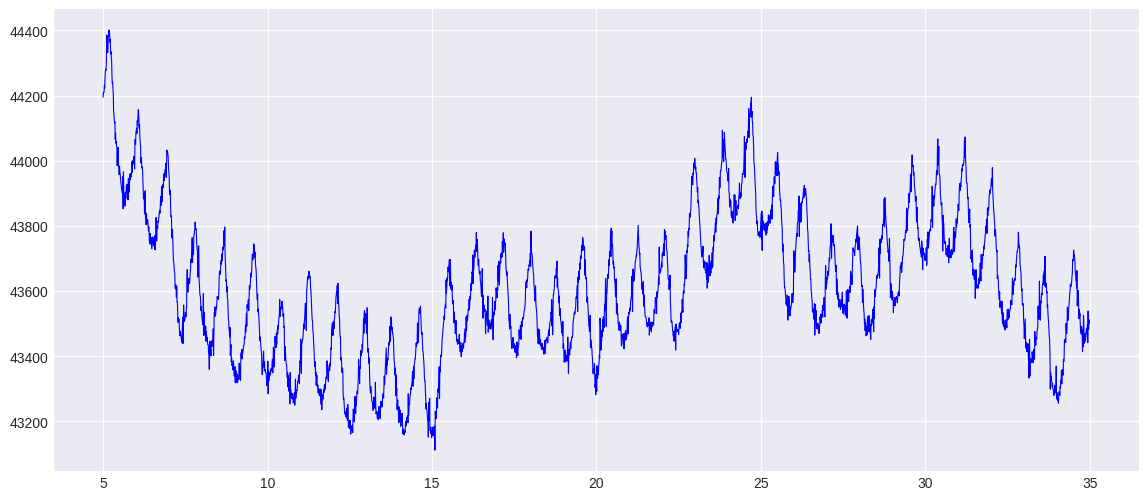

In [ ]:
plt.plot(time[500: 3500], ppg_green[500:3500], 'b-', linewidth=0.8, label='Raw PPG (Green)')

#Question
Describe the ppg signal obtained in terms of the units of measurement, the trend and the periodicity. Why may the signal amplitude range change from ~45000 to ~43400?

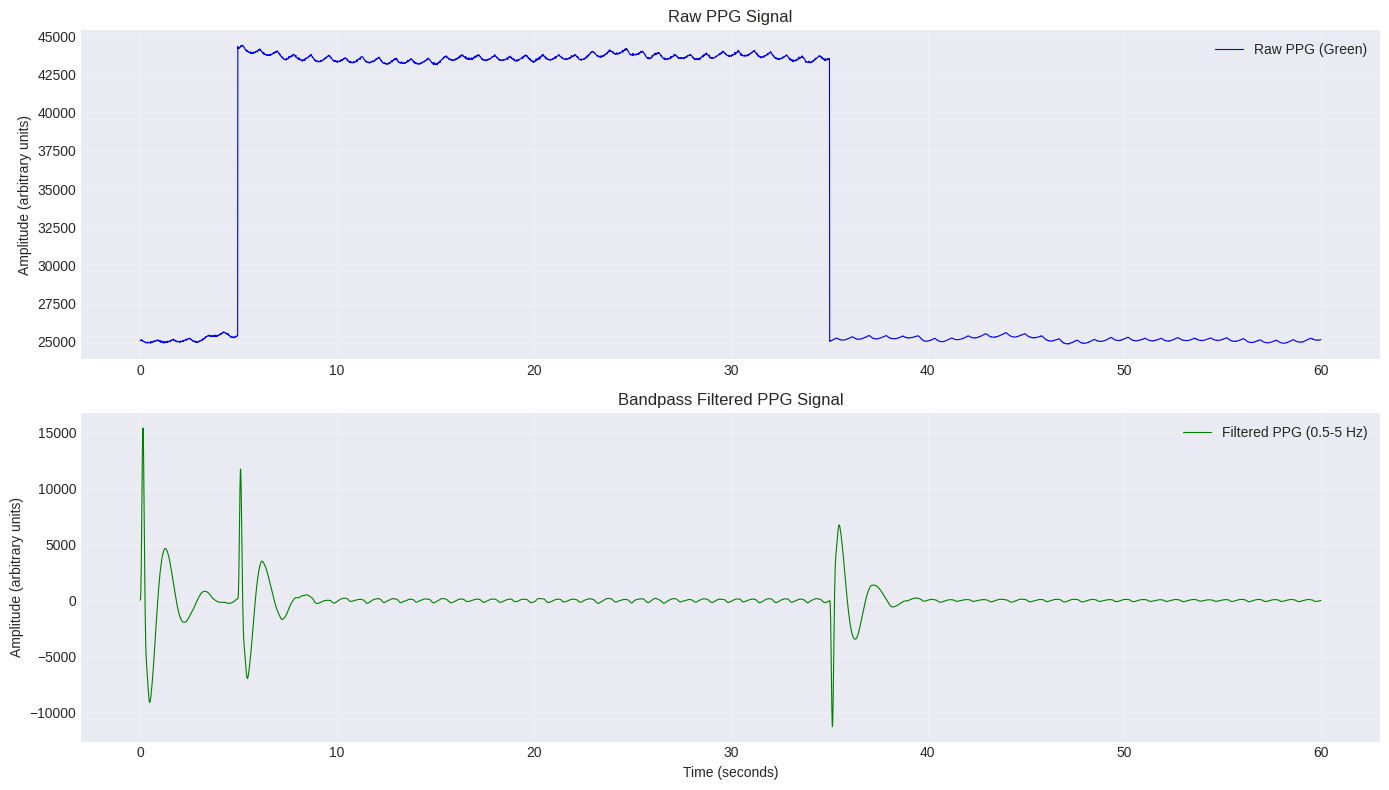

Raw signal range: [24868, 44401]
Filtered signal range: [-11250.82, 15361.09]


In [ ]:
# Plot raw vs filtered signal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw PPG
axes[0].plot(time, ppg_green, 'b-', linewidth=0.8, label='Raw PPG (Green)')
axes[0].set_ylabel('Amplitude (arbitrary units)')
axes[0].set_title('Raw PPG Signal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Filtered PPG
axes[1].plot(time, ppg_filtered, 'g-', linewidth=0.8, label='Filtered PPG (0.5-5 Hz)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (arbitrary units)')
axes[1].set_title('Bandpass Filtered PPG Signal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Raw signal range: [{ppg_green.min():.0f}, {ppg_green.max():.0f}]")
print(f"Filtered signal range: [{ppg_filtered.min():.2f}, {ppg_filtered.max():.2f}]")

#Question
Does the shape of the obtained filtered ppg correspond to the expected ppg signal?

What do the peaks observed correspond to?

#Exploring other filters


### Task 1.3: Normalize and Detrend

**Why detrending?**
- Removes DC offset (constant added to signal)
- Removes slow drift (low-frequency components not removed by bandpass)
- Normalizes amplitude for consistent peak detection


In [ ]:
# Remove DC offset
ppg_demeaned = ppg_filtered - np.mean(ppg_filtered)

# Normalize to unit variance
ppg_normalized = ppg_demeaned / np.std(ppg_demeaned)

print(f"After normalization:")
print(f"  Mean: {np.mean(ppg_normalized):.6f} (should be ~0)")
print(f"  Std: {np.std(ppg_normalized):.6f} (should be ~1)")
print(f"  Range: [{ppg_normalized.min():.2f}, {ppg_normalized.max():.2f}]")

After normalization:
  Mean: -0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)
  Range: [-7.85, 10.50]


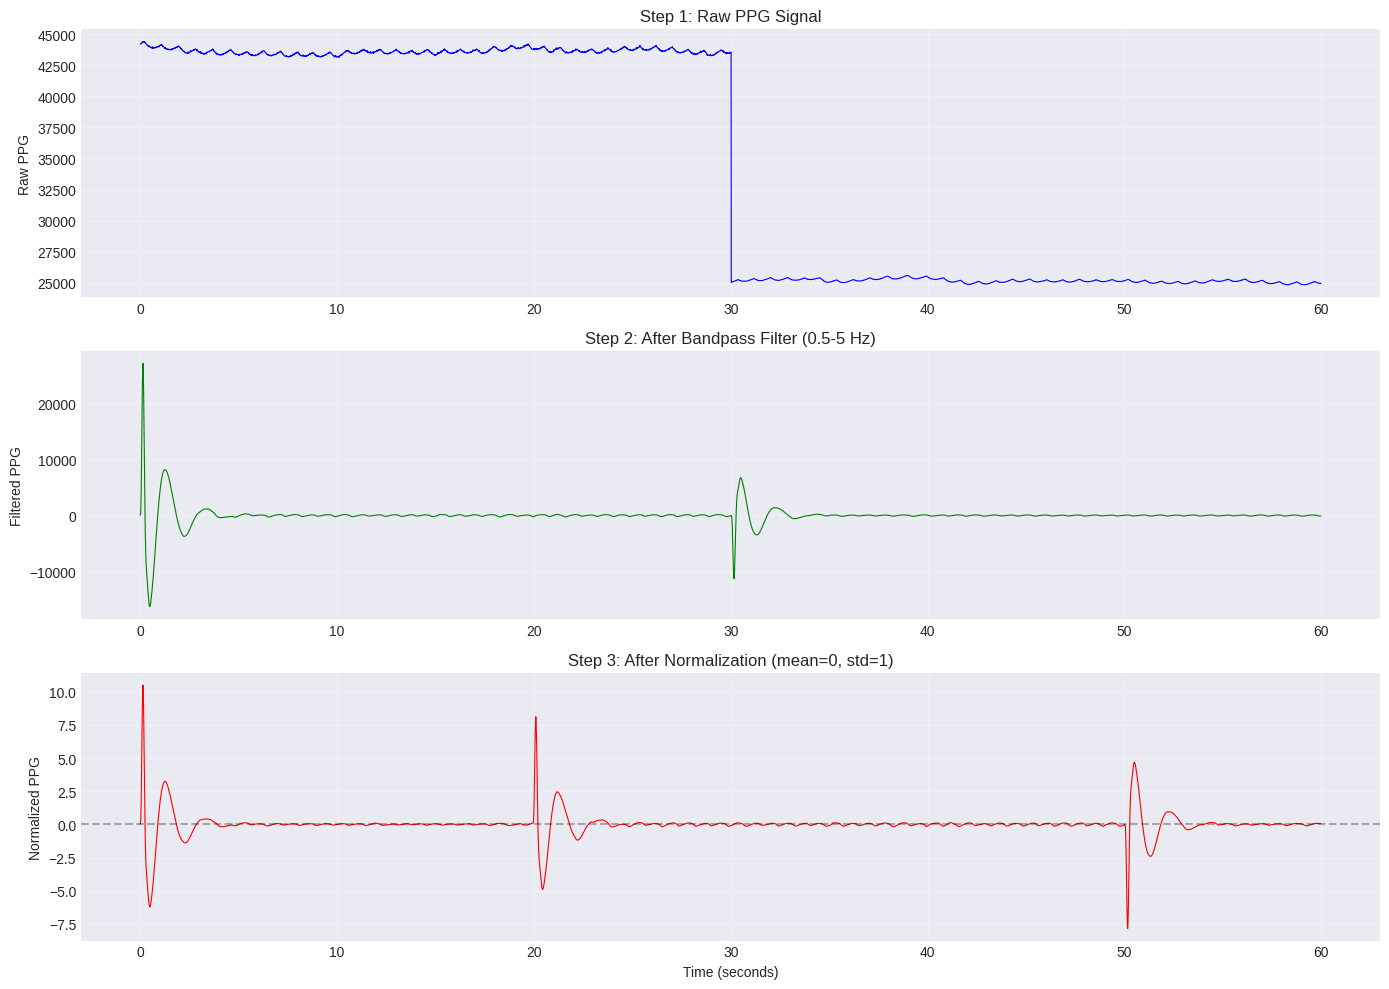

In [ ]:
# Visualize preprocessing progression
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw signal
axes[0].plot(time, ppg_green, 'b-', linewidth=0.8)
axes[0].set_ylabel('Raw PPG')
axes[0].set_title('Step 1: Raw PPG Signal')
axes[0].grid(True, alpha=0.3)

# Filtered signal
axes[1].plot(time, ppg_filtered, 'g-', linewidth=0.8)
axes[1].set_ylabel('Filtered PPG')
axes[1].set_title('Step 2: After Bandpass Filter (0.5-5 Hz)')
axes[1].grid(True, alpha=0.3)

# Normalized signal
axes[2].plot(time, ppg_normalized, 'r-', linewidth=0.8)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Normalized PPG')
axes[2].set_title('Step 3: After Normalization (mean=0, std=1)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Beat Detection

### Task 1.4: Detect Systolic Peaks

**Background:**
PPG peaks correspond to systolic upstrokes - the moment when blood pressure is highest. Each peak = one heartbeat.

**Strategy:**
1. Find local maxima in filtered signal
2. Apply height threshold (must be above noise)
3. Apply distance constraint (peaks must be 0.4+ seconds apart for HR < 150 bpm)


In [ ]:
# Peak detection using scipy.signal.find_peaks
# Set parameters based on signal properties

# Height threshold: mean + 1*std
height_threshold = np.mean(ppg_normalized) + 1.0 * np.std(ppg_normalized)

# Distance constraint: minimum samples between peaks
# For HR range 40-200 bpm, minimum interval is 60/200 * fs = 30 samples
# Conservative: require min 0.4s = 40 samples
min_distance_samples = int(0.4 * fs)

# Detect peaks
peak_indices, properties = find_peaks(
    ppg_normalized,
    height=height_threshold,
    distance=min_distance_samples
)

print(f"Peak Detection Parameters:")
print(f"  Height threshold: {height_threshold:.2f}")
print(f"  Minimum distance: {min_distance_samples} samples ({min_distance_samples/fs:.2f}s)")
print(f"\nDetection Results:")
print(f"  Peaks detected: {len(peak_indices)}")
print(f"  Duration: {duration_sec}s")
print(f"  Apparent HR: {len(peak_indices) * 60 / duration_sec:.1f} bpm")

Peak Detection Parameters:
  Height threshold: 1.00
  Minimum distance: 40 samples (0.40s)

Detection Results:
  Peaks detected: 5
  Duration: 60s
  Apparent HR: 5.0 bpm


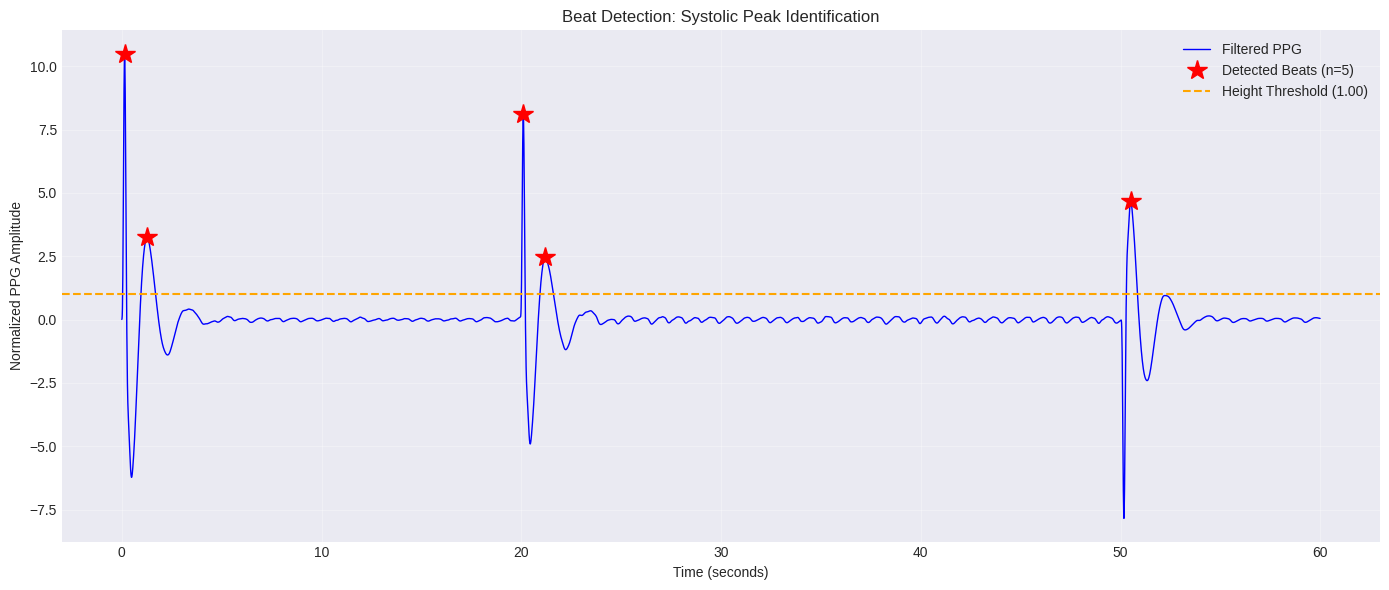

In [ ]:
# Visualize beat detection
fig, ax = plt.subplots(figsize=(14, 6))

# Plot filtered signal
ax.plot(time, ppg_normalized, 'b-', linewidth=1, label='Filtered PPG')

# Plot detected peaks
peak_times = peak_indices / fs
peak_heights = ppg_normalized[peak_indices]
ax.plot(peak_times, peak_heights, 'r*', markersize=15, label=f'Detected Beats (n={len(peak_indices)})')

# Plot threshold line
ax.axhline(y=height_threshold, color='orange', linestyle='--', linewidth=1.5,
           label=f'Height Threshold ({height_threshold:.2f})')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Normalized PPG Amplitude')
ax.set_title('Beat Detection: Systolic Peak Identification')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Question
Is the obtained heart rate reasonable? How many peaks should we expect on average?

#Task
Modify the code to obtain the real peaks.
- First: obtain a segment of signal without abrupt changes of amplitude, follow the same steps (filter, identify peaks.
-Second: can you change the code to that automatically for all segments?

## Section 5: Heart Rate and RR Interval Analysis

### Task 1.5: Compute Heart Rate

In [ ]:
# Compute RR intervals (in milliseconds)
# RR = time between consecutive R-waves (peaks)

rr_intervals = np.diff(peak_indices) / fs * 1000  # Convert to milliseconds

# Compute instantaneous HR from RR intervals
# HR = 60,000 / RR_interval (converts ms to bpm)
instantaneous_hr = 60000 / rr_intervals

# Mean HR
mean_hr = np.mean(instantaneous_hr)

print(f"RR Interval Analysis:")
print(f"  Mean RR interval: {np.mean(rr_intervals):.1f} ms")
print(f"  Std RR interval: {np.std(rr_intervals):.1f} ms")
print(f"  Min RR interval: {np.min(rr_intervals):.1f} ms")
print(f"  Max RR interval: {np.max(rr_intervals):.1f} ms")

print(f"\nHeart Rate Analysis:")
print(f"  Mean HR: {mean_hr:.1f} bpm")
print(f"  Min HR: {np.min(instantaneous_hr):.1f} bpm")
print(f"  Max HR: {np.max(instantaneous_hr):.1f} bpm")
print(f"  HR Std: {np.std(instantaneous_hr):.1f} bpm")

RR Interval Analysis:
  Mean RR interval: 12592.5 ms
  Std RR interval: 12066.6 ms
  Min RR interval: 1090.0 ms
  Max RR interval: 29320.0 ms

Heart Rate Analysis:
  Mean HR: 28.3 bpm
  Min HR: 2.0 bpm
  Max HR: 55.0 bpm
  HR Std: 25.7 bpm


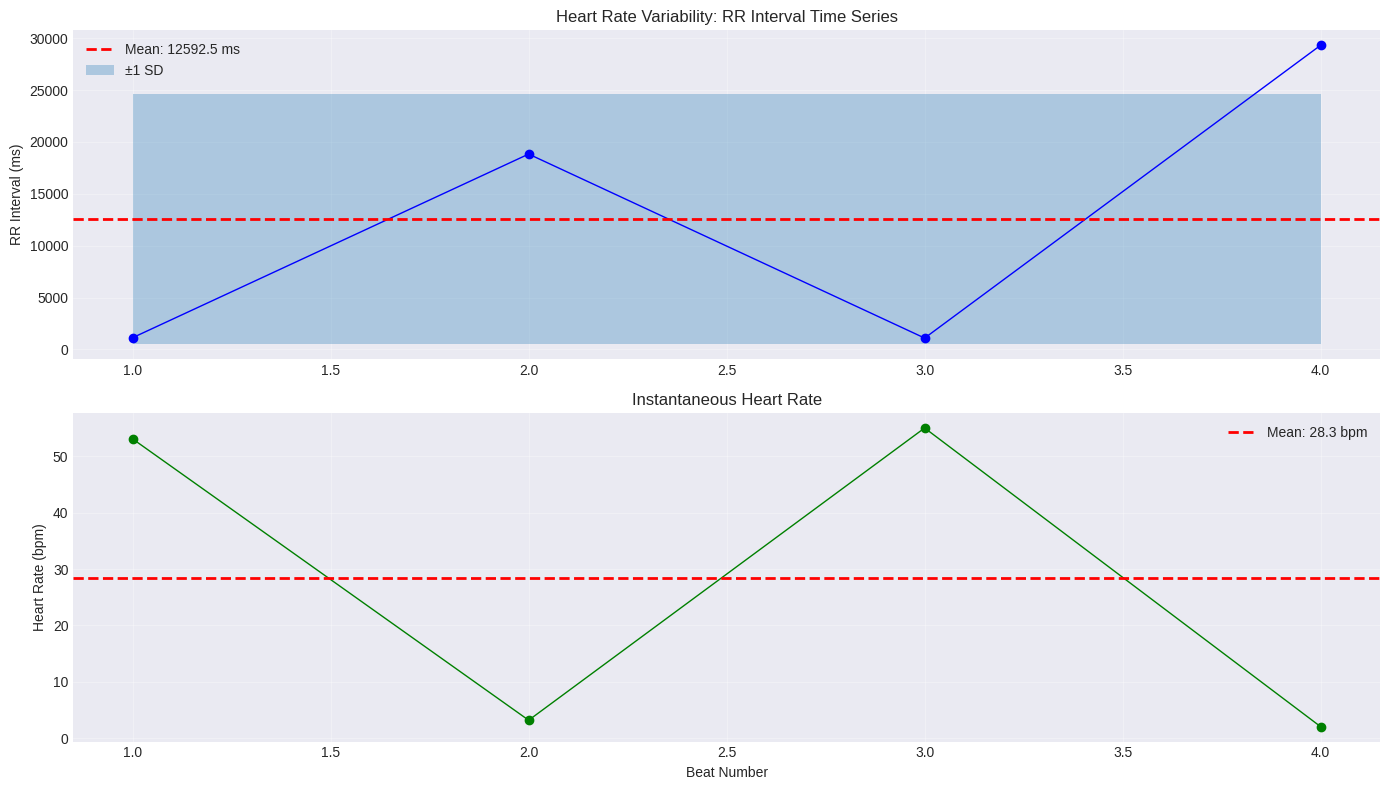

In [ ]:
# Visualize RR intervals
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# RR interval time series
beat_numbers = np.arange(1, len(rr_intervals) + 1)
axes[0].plot(beat_numbers, rr_intervals, 'bo-', markersize=6, linewidth=1)
axes[0].axhline(y=np.mean(rr_intervals), color='r', linestyle='--', linewidth=2,
               label=f'Mean: {np.mean(rr_intervals):.1f} ms')
axes[0].fill_between(beat_numbers,
                     np.mean(rr_intervals) - np.std(rr_intervals),
                     np.mean(rr_intervals) + np.std(rr_intervals),
                     alpha=0.3, label='±1 SD')
axes[0].set_ylabel('RR Interval (ms)')
axes[0].set_title('Heart Rate Variability: RR Interval Time Series')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# HR time series
axes[1].plot(beat_numbers, instantaneous_hr, 'go-', markersize=6, linewidth=1)
axes[1].axhline(y=mean_hr, color='r', linestyle='--', linewidth=2,
                label=f'Mean: {mean_hr:.1f} bpm')
axes[1].set_xlabel('Beat Number')
axes[1].set_ylabel('Heart Rate (bpm)')
axes[1].set_title('Instantaneous Heart Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Heart Rate Variability Metrics

### Task 1.6: Compute HRV Metrics

**Background:**
Heart rate variability reflects autonomic nervous system activity:
- High HRV → Good parasympathetic (relaxation) control
- Low HRV → Sympathetic (stress) dominance or poor health

**Metrics:**
1. **SDNN**: Standard deviation of normal intervals (overall variability)
2. **pNN50**: % of intervals differing >50ms (parasympathetic activity)
3. **RMSSD**: Root mean square of successive differences (short-term variability)

**Reference:**
Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology (1996). "Heart rate variability: standards of measurement, physiological interpretation and clinical use." Circulation, 93(5), 1043-1065.

In [ ]:
# SDNN: Standard Deviation of NN intervals
sdnn = np.std(rr_intervals, ddof=1)

# pNN50: Percentage of NN intervals differing >50 ms
nn_differences = np.abs(np.diff(rr_intervals))
pnn50 = 100 * np.sum(nn_differences > 50) / len(nn_differences)

# RMSSD: Root Mean Square of Successive Differences
rmssd = np.sqrt(np.mean(nn_differences ** 2))

print("Time-Domain HRV Metrics (At-Rest Baseline):")
print(f"  SDNN: {sdnn:.1f} ms")
print(f"    → Overall heart rate variability")
print(f"    → Typical resting range: 50-100 ms")

print(f"\n  pNN50: {pnn50:.1f}%")
print(f"    → Percentage of successive intervals >50ms apart")
print(f"    → Typical resting range: 25-50%")
print(f"    → Reflects parasympathetic (vagal) activity")

print(f"\n  RMSSD: {rmssd:.1f} ms")
print(f"    → Short-term heart rate fluctuations")
print(f"    → Typical resting range: 20-50 ms")
print(f"    → Also reflects parasympathetic activity")

Time-Domain HRV Metrics (At-Rest Baseline):
  SDNN: 13933.3 ms
    → Overall heart rate variability
    → Typical resting range: 50-100 ms

  pNN50: 100.0%
    → Percentage of successive intervals >50ms apart
    → Typical resting range: 25-50%
    → Reflects parasympathetic (vagal) activity

  RMSSD: 21794.0 ms
    → Short-term heart rate fluctuations
    → Typical resting range: 20-50 ms
    → Also reflects parasympathetic activity


In [ ]:
# Compute frequency-domain HRV (optional, more advanced)
# This requires interpolation of RR intervals to regular grid

# Create time array for RR intervals
rr_times = np.cumsum(rr_intervals) / 1000  # Convert back to seconds

# Create regular time grid at 4 Hz (common for HRV analysis)
regular_time = np.arange(0, rr_times[-1], 0.25)

# Interpolate RR intervals
rr_interpolated = np.interp(regular_time, rr_times, rr_intervals)

# Compute power spectral density using Welch's method
freqs, psd = signal.welch(rr_interpolated, fs=4, nperseg=min(256, len(rr_interpolated)))

# Define frequency bands
# VLF: 0.0033-0.04 Hz (very low frequency)
# LF: 0.04-0.15 Hz (low frequency) - sympathetic activity
# HF: 0.15-0.4 Hz (high frequency) - parasympathetic activity

lf_band = (freqs >= 0.04) & (freqs <= 0.15)
hf_band = (freqs >= 0.15) & (freqs <= 0.4)

lf_power = np.trapz(psd[lf_band], freqs[lf_band])
hf_power = np.trapz(psd[hf_band], freqs[hf_band])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else np.nan

print(f"\nFrequency-Domain HRV Metrics:")
print(f"  LF Power (0.04-0.15 Hz): {lf_power:.2f}")
print(f"  HF Power (0.15-0.4 Hz): {hf_power:.2f}")
print(f"  LF/HF Ratio: {lf_hf_ratio:.2f}")
print(f"    → At rest, should be <2.0")
print(f"    → During stress, increases >2.0")


Frequency-Domain HRV Metrics:
  LF Power (0.04-0.15 Hz): 8256441.63
  HF Power (0.15-0.4 Hz): 2387385.74
  LF/HF Ratio: 3.46
    → At rest, should be <2.0
    → During stress, increases >2.0


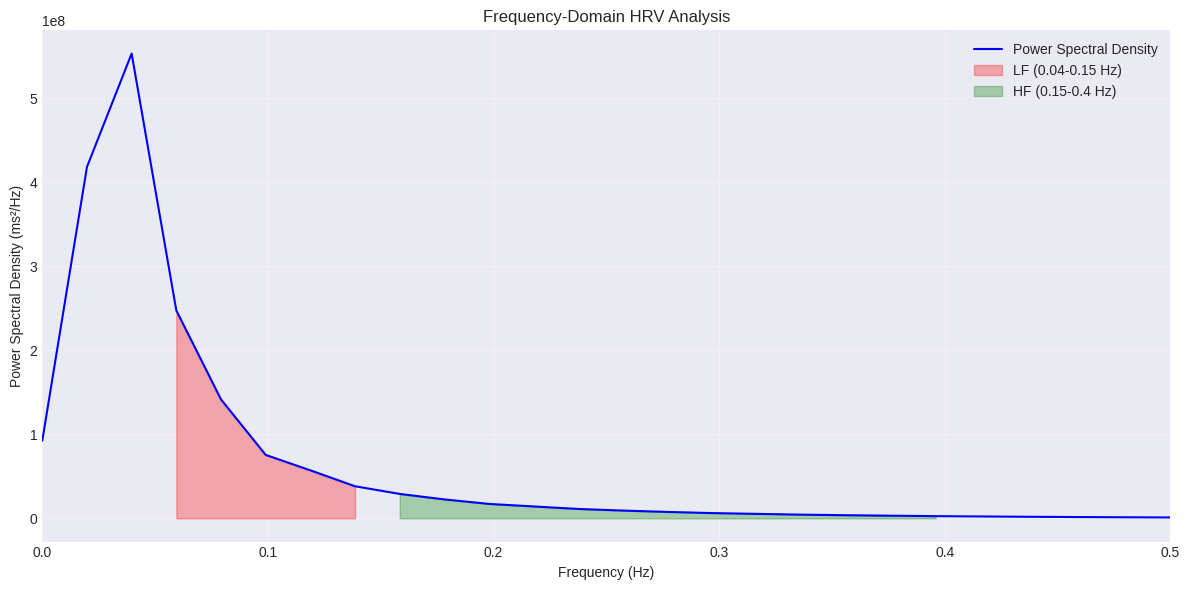

In [ ]:
# Plot frequency domain analysis
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(freqs, psd, 'b-', linewidth=1.5, label='Power Spectral Density')
ax.fill_between(freqs[lf_band], 0, psd[lf_band], alpha=0.3, color='red', label='LF (0.04-0.15 Hz)')
ax.fill_between(freqs[hf_band], 0, psd[hf_band], alpha=0.3, color='green', label='HF (0.15-0.4 Hz)')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (ms²/Hz)')
ax.set_title('Frequency-Domain HRV Analysis')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

## Section 7: Signal Quality Assessment

### Task 1.7: Evaluate Signal Quality

**Why assess quality?**
Not all detected beats are correct, and not all good data has detectable beats. Quality metrics help you trust your results.

**Indicators of good signal quality:**
1. Regular RR intervals (low variability around mean)
2. Consistent peak heights and shapes
3. Low noise (high signal-to-noise ratio)
4. Physiologically plausible HR (40-200 bpm)

In [ ]:
# Compute signal quality index

# 1. RR interval regularity (CV = coefficient of variation)
rr_cv = np.std(rr_intervals) / np.mean(rr_intervals)
regularity_score = 1.0 / (1.0 + rr_cv)  # Peaks at 1.0 for perfect regularity

# 2. Signal-to-noise ratio (based on peak heights)
peak_heights = ppg_normalized[peak_indices]
snr = np.std(peak_heights) / (np.std(ppg_normalized) + 1e-10)
snr_score = np.tanh(snr / 2)  # Normalize to [0, 1]

# 3. Heart rate physiological plausibility
hr_plausible = np.all((instantaneous_hr > 30) & (instantaneous_hr < 200))
hr_score = 1.0 if hr_plausible else 0.5

# Combined SQI
sqi = 0.4 * regularity_score + 0.3 * snr_score + 0.3 * hr_score

print(f"Signal Quality Index (SQI) Components:")
print(f"  Regularity Score: {regularity_score:.2f} (RR interval consistency)")
print(f"    → RR CV: {rr_cv:.2f}")
print(f"  SNR Score: {snr_score:.2f} (signal-to-noise ratio)")
print(f"    → SNR: {snr:.2f}")
print(f"  HR Plausibility: {hr_score:.2f} (HR in range 30-200 bpm)")
print(f"\n  OVERALL SQI: {sqi:.2f}")
print(f"  Interpretation:")
if sqi > 0.8:
    print(f"    → EXCELLENT quality, results highly reliable")
elif sqi > 0.6:
    print(f"    → GOOD quality, results generally reliable")
elif sqi > 0.4:
    print(f"    → ACCEPTABLE quality, use with caution")
else:
    print(f"    → POOR quality, results unreliable")

Signal Quality Index (SQI) Components:
  Regularity Score: 0.51 (RR interval consistency)
    → RR CV: 0.96
  SNR Score: 0.91 (signal-to-noise ratio)
    → SNR: 3.05
  HR Plausibility: 0.50 (HR in range 30-200 bpm)

  OVERALL SQI: 0.63
  Interpretation:
    → GOOD quality, results generally reliable


## Section 8: Validation Against heartPy

### Task 1.5 Continued: Compare with heartPY Reference

**Why validate?**
Comparing your results validates your approach.

**References:**

https://github.com/paulvangentcom/heartrate_analysis_python/blob/master/examples/1_regular_PPG/Analysing_a_PPG_signal.ipynb

First create a clean file. The following code converts to numeric and interpolates, but you also need to filter the signal (remove respiration and remove the big changes of amplitude)

In [ ]:
# Create a copy to avoid modifying the original DataFrame directly if it's used elsewhere
cleaned_ppg_data = ppg_data.copy()

# 1. Clean the 'timestamp' column: remove '#' and convert to int
cleaned_ppg_data['timestamp'] = cleaned_ppg_data['timestamp'].astype(str).str.replace('#', '', regex=False).astype(int)

# 2. Clean the 'green' column: convert to numeric, coerce errors, and interpolate NaNs
cleaned_ppg_data['green'] = pd.to_numeric(cleaned_ppg_data['green'], errors='coerce')
cleaned_ppg_data['green'] = cleaned_ppg_data['green'].interpolate(method='linear', limit_direction='both')

# Optional: You might want to do similar cleaning for 'ir' and 'red' if they can have non-numeric values
cleaned_ppg_data['ir'] = pd.to_numeric(cleaned_ppg_data['ir'], errors='coerce').interpolate(method='linear', limit_direction='both')
cleaned_ppg_data['red'] = pd.to_numeric(cleaned_ppg_data['red'], errors='coerce').interpolate(method='linear', limit_direction='both')

cleaned_ppg_data = cleaned_ppg_data.iloc[3000:6000]

# Display the head of the cleaned data and its info to verify types
print("Cleaned PPG Data Head:")
print(cleaned_ppg_data.head())
print("\nCleaned PPG Data Info:")
print(cleaned_ppg_data.describe())

# Save the cleaned data to a new CSV file WITH HEADER
output_file_path = dataset_path / 'cleaned_ppg_data.csv'
cleaned_ppg_data.to_csv(output_file_path, index=False, header=False, columns=['green'])
print(f"\nCleaned data saved to: {output_file_path}")

Cleaned PPG Data Head:
          timestamp    green        ir       red
3000  1621421129326  44195.0  151392.0  212344.0
3001  1621421129336  44210.0  151387.0  212343.0
3002  1621421129346  44208.0  151464.0  212345.0
3003  1621421129356  44212.0  151434.0  212318.0
3004  1621421129366  44232.0  151431.0  212284.0

Cleaned PPG Data Info:
          timestamp         green             ir            red
count  3.000000e+03   3000.000000    3000.000000    3000.000000
mean   1.621421e+12  43609.802667  154039.185167  212271.705000
std    8.661701e+03    221.191532     763.983646     275.715396
min    1.621421e+12  43112.000000  150989.000000  211371.000000
25%    1.621421e+12  43459.000000  153710.750000  212143.000000
50%    1.621421e+12  43585.000000  154105.000000  212299.000000
75%    1.621421e+12  43749.000000  154642.500000  212462.000000
max    1.621421e+12  44401.000000  155340.000000  212841.000000

Cleaned data saved to: /content/Dataset/cleaned_ppg_data.csv


In [ ]:
import heartpy as hp
hrdata = hp.get_data('/content/Dataset/cleaned_ppg_data.csv')
working_data, measures = hp.process(hrdata, 100.0)


BadSignalWarning: 
----------------
Could not determine best fit for given signal. Please check the source signal.
 Probable causes:
- detected heart rate falls outside of bpmmin<->bpmmax constraints
- no detectable heart rate present in signal
- very noisy signal (consider filtering and scaling)
If you're sure the signal contains heartrate data, consider filtering and/or scaling first.
----------------


## Reflection Questions

Before moving to Stage 2, answer these questions in your notebook:

1. **Filtering Design**
   - Why did you choose 0.5-5 Hz bandpass cutoffs? What happens at the boundaries?
   - What would happen if you used 0.1-10 Hz instead? Would results improve?
   - Sketch the frequency response of your Butterworth filter

2. **Beat Detection**
   - How did you choose the height threshold? Experiment with different values.
   - What happens if you decrease the minimum distance between peaks?
   - Are there any false positives or missed beats in your visualization?

3. **HRV Interpretation**
   - Is your SDNN in the normal at-rest range? What does this tell you?
   - Is your LF/HF ratio <2.0 (indicating parasympathetic dominance)?
   - How do your metrics compare to literature values?

4. **Signal Quality**
   - What aspects of your signal quality score are strongest? Weakest?
   - If quality is poor, what might be wrong?
   - How would you improve the signal preprocessing?

5. **Next Steps**
   - Why do we need Stage 2 (motion artifact filtering)?
   - What happens to PPG signals during movement?
   - Why is frequency analysis useful for motion artifact removal?

## References

1. Allen, J. (2007). "Photoplethysmography and its application in clinical physiological measurement." *Physiological Measurement*, 28(3), R1-R39.
   - Foundational paper on PPG principles and clinical applications

2. Charlton, P. H., Marozas, V., Chowienczyk, P., & Białkowski, J. (2016). "Wearable photoplethysmography for cardiovascular monitoring." *Proceedings of the IEEE*, 104(11), 2288-2303.
   - Comprehensive review of wearable PPG technology and signal processing

3. Goda, M. A., Charlton, P. H., & Behar, J. A. (2023). "pyPPG: A Python toolbox for comprehensive photoplethysmography signal analysis." *IEEE Transactions on Biomedical Engineering*, 70(11).
   - Reference implementation and benchmark for PPG analysis

4. Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology (1996). "Heart rate variability: standards of measurement, physiological interpretation and clinical use." *Circulation*, 93(5), 1043-1065.
   - Clinical standard for HRV metrics and interpretation

5. Elgendi, M. (2016). "Optimal signal processing methods for photoplethysmography non-contact heart rate monitors." *Health and Technology*, 4(1), 21-32.
   - Peak detection strategies for PPG signals

6. Montanari, A., Ferlini, A., et al. (2023). "EarSet: A multi-modal dataset for studying the impact of head and facial movements on in-ear PPG signals." *Nature Scientific Data*, 10, 759.
   - Description of EarSet dataset used in this assignment